# 🔷 Modèle CNN — Détection de Commentaires Toxiques
**Dataset :** Jigsaw Toxic Comment Classification  
**Architecture :** CNN 1D Multi-kernel (TextCNN)  
>

## 1. 📦 Imports

In [ ]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, SpatialDropout1D, Concatenate,
    BatchNormalization
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU disponible     : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.19.0
GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. 🔗 Connexion Drive & Chargement

In [ ]:

gdown.download('https://drive.google.com/uc?id=1Z2zgdnGuD61vJ0QtfPGlvmjvM6x1LHUq', 'train.csv', quiet=False)
gdown.download('https://drive.google.com/uc?id=1uDzllIpQ-08vlNlG21k5xVk2WdrOeTVz', 'test.csv', quiet=False)# ──────────────────────────────────────────────────────────────────────────────

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
train_df.head(3)

Mounted at /content/drive
Train shape : (159571, 8)
Test  shape : (153164, 2)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


## 3. 🧹 Preprocessing

In [ ]:
LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# ─── Hyperparamètres ──────────────────────────────────────────────────────────
MAX_FEATURES   = 30000
MAX_LEN        = 200
EMBED_DIM      = 128
NUM_FILTERS    = 128         # filtres par taille de kernel
KERNEL_SIZES   = [2, 3, 4, 5]  # n-grams capturés
DROPOUT_RATE   = 0.3
BATCH_SIZE     = 512          # CNN plus rapide → batch plus grand
EPOCHS         = 10
VAL_SPLIT      = 0.1
# ──────────────────────────────────────────────────────────────────────────────

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)
    text = re.sub(r'[^a-z0-9\s!?.,]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Nettoyage...')
train_df['clean_text'] = train_df['comment_text'].apply(clean_text)
test_df['clean_text']  = test_df['comment_text'].apply(clean_text)

print('Tokenisation...')
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

X_train_pad = pad_sequences(
    tokenizer.texts_to_sequences(train_df['clean_text']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_pad  = pad_sequences(
    tokenizer.texts_to_sequences(test_df['clean_text']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

y = train_df[LABELS].values
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y, test_size=VAL_SPLIT, random_state=42, stratify=y[:, 0]
)
print(f'X_train : {X_tr.shape} | X_val : {X_val.shape}')

Nettoyage...
Tokenisation...
X_train : (143613, 200) | X_val : (15958, 200)


## 4. 🏗️ Architecture TextCNN Multi-kernel
> L'idée : plusieurs filtres en parallèle capturent des n-grams de tailles différentes (bigrammes, trigrammes...).  
> C'est l'architecture proposée par Kim (2014) — *Convolutional Neural Networks for Sentence Classification*.

In [ ]:
def build_textcnn_model(vocab_size, embed_dim, max_len,
                        num_filters, kernel_sizes, dropout_rate, n_labels=6):
    """TextCNN avec filtres parallèles de tailles multiples."""
    inputs = Input(shape=(max_len,), name='input')

    # Embedding partagé
    x = Embedding(vocab_size, embed_dim, input_length=max_len, name='embedding')(inputs)
    x = SpatialDropout1D(dropout_rate)(x)

    # Branches parallèles : une par kernel size
    branches = []
    for k in kernel_sizes:
        # Conv1D → BatchNorm → GlobalMaxPool
        branch = Conv1D(
            filters=num_filters, kernel_size=k,
            activation='relu', padding='same',
            name=f'conv_{k}gram'
        )(x)
        branch = BatchNormalization(name=f'bn_{k}gram')(branch)
        branch = GlobalMaxPooling1D(name=f'pool_{k}gram')(branch)
        branches.append(branch)

    # Fusion de toutes les branches
    merged = Concatenate(name='concat')(branches) if len(branches) > 1 else branches[0]
    merged = Dropout(dropout_rate)(merged)

    # Classifieur
    out = Dense(256, activation='relu', name='dense_1')(merged)
    out = Dropout(0.3)(out)
    out = Dense(128, activation='relu', name='dense_2')(out)
    out = Dropout(0.2)(out)
    out = Dense(n_labels, activation='sigmoid', name='output')(out)

    model = Model(inputs=inputs, outputs=out, name='TextCNN_ToxicDetector')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return model


model_cnn = build_textcnn_model(
    vocab_size=MAX_FEATURES + 1,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    dropout_rate=DROPOUT_RATE
)
model_cnn.summary()
print(f'\nKernels utilisés   : {KERNEL_SIZES} → capture des {KERNEL_SIZES[0]}-grams à {KERNEL_SIZES[-1]}-grams')
print(f'Filtres par kernel : {NUM_FILTERS}')
print(f'Total branches     : {len(KERNEL_SIZES)} × {NUM_FILTERS} = {len(KERNEL_SIZES)*NUM_FILTERS} features')

Model: "TextCNN_ToxicDetector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  3,840,128 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2gram (Conv1D) │ (None, 200, 128)  │     32,896 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3gram (Conv1D) │ (None, 200, 128)  │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4gram (Conv1D) │ (None, 200, 128)  │     65,664 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5gram (Conv1D) │ (None, 200, 128)  │     82,048 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2gram            │ (None, 200, 128)  │        512 │ conv_2gram[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3gram            │ (None, 200, 128)  │        512 │ conv_3gram[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_4gram            │ (None, 200, 128)  │        512 │ conv_4gram[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_5gram            │ (None, 200, 128)  │        512 │ conv_5gram[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2gram          │ (None, 128)       │          0 │ bn_2gram[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3gram          │ (None, 128)       │          0 │ bn_3gram[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4gram          │ (None, 128)       │          0 │ bn_4gram[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_5gram          │ (None, 128)       │          0 │ bn_5gram[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 512)       │          0 │ pool_2gram[0][0], │
│ (Concatenate)       │                   │            │ pool_3gram[0][0], │
│                     │                   │            │ pool_4gram[0][0], │
│                     │                   │            │ pool_5gram[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,237,062 (16.16 MB)

 Trainable params: 4,236,038 (16.16 MB)

 Non-trainable params: 1,024 (4.00 KB)


Kernels utilisés   : [2, 3, 4, 5] → capture des 2-grams à 5-grams
Filtres par kernel : 128
Total branches     : 4 × 128 = 512 features


## 5. 🏋️ Entraînement

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=3, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=2,
                     mode='max', min_lr=1e-5, verbose=1),
    ModelCheckpoint(
        filepath=os.path.join(RESULTS_DIR, 'best_cnn.keras'),
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

t0 = time.time()
history_cnn = model_cnn.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
train_time_cnn = time.time() - t0
print(f'\nTemps entraînement : {train_time_cnn/60:.1f} min')

Epoch 1/10
280/281 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9705 - auc: 0.9845 - loss: 0.0338
Epoch 1: val_auc improved from None to 0.96173, saving model to /content/drive/MyDrive/toxic_comment_project/results/best_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/toxic_comment_project/results/best_cnn.keras
281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.9651 - auc: 0.9840 - loss: 0.0340 - val_accuracy: 0.9952 - val_auc: 0.9617 - val_loss: 0.0533 - learning_rate: 2.5000e-04
Epoch 2/10
280/281 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9588 - auc: 0.9874 - loss: 0.0315
Epoch 2: val_auc did not improve from 0.96173
281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.9564 - auc: 0.9877 - loss: 0.0322 - val_accuracy: 0.9949 - val_auc: 0.9614 - val_loss: 0.0534 - learning_rate: 2.5000e-04
Epoch 3/10
280/281 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9534 - auc: 0.9878 - loss: 0.0306
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.000

## 6. 📈 Courbes d'apprentissage

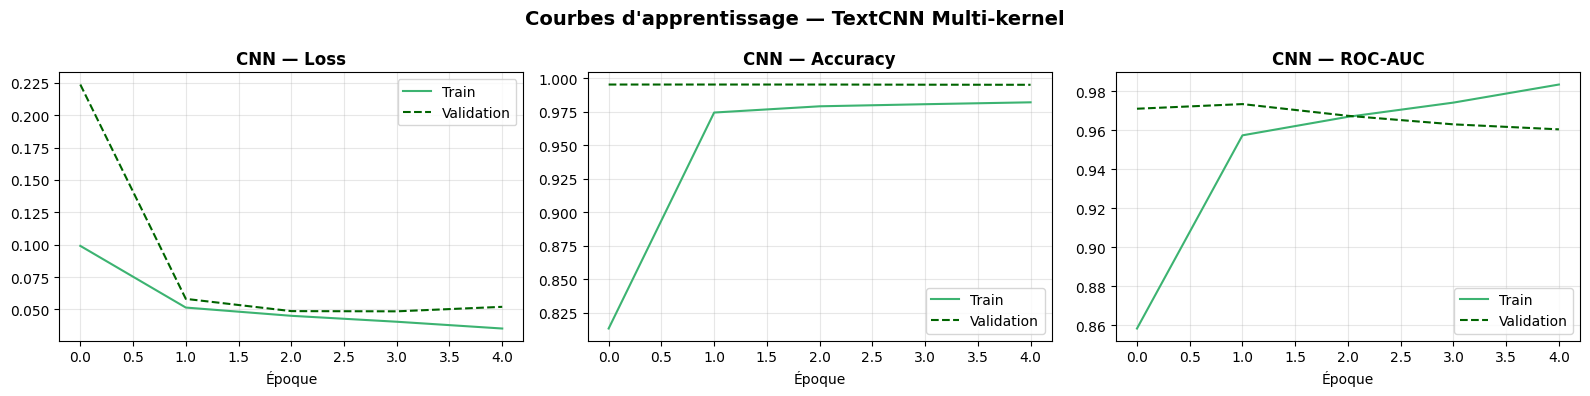

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hist = history_cnn.history
metrics_plot = [('loss', 'Loss'), ('accuracy', 'Accuracy'), ('auc', 'ROC-AUC')]

for ax, (m, title) in zip(axes, metrics_plot):
    ax.plot(hist[m], label='Train', color='mediumseagreen')
    ax.plot(hist[f'val_{m}'], label='Validation', color='darkgreen', linestyle='--')
    ax.set_title(f'CNN — {title}', fontweight='bold')
    ax.set_xlabel('Époque')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Courbes d\'apprentissage — TextCNN Multi-kernel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cnn_history.png'), dpi=150)
plt.show()

## 7. 📊 Évaluation

In [ ]:
def evaluate_model(model, X_val, y_val, model_name='Modèle', threshold=0.5):
    y_proba = model.predict(X_val, batch_size=512, verbose=0)
    y_pred  = (y_proba >= threshold).astype(int)

    roc_macro = roc_auc_score(y_val, y_proba, average='macro')
    f1_macro  = f1_score(y_val, y_pred, average='macro',    zero_division=0)
    f1_micro  = f1_score(y_val, y_pred, average='micro',    zero_division=0)
    f1_weight = f1_score(y_val, y_pred, average='weighted', zero_division=0)

    print(f'\n{"═"*50}\n  {model_name}\n{"═"*50}')
    print(f'  ROC-AUC macro : {roc_macro:.4f}')
    print(f'  F1 macro      : {f1_macro:.4f}')
    print(f'  F1 micro      : {f1_micro:.4f}')
    print(f'  F1 weighted   : {f1_weight:.4f}\n')

    auc_per_label = {}
    for i, label in enumerate(LABELS):
        auc_l = roc_auc_score(y_val[:, i], y_proba[:, i])
        auc_per_label[label] = auc_l
        print(f'    {label:20s} → AUC = {auc_l:.4f}')

    return {
        'roc_auc_macro': roc_macro, 'f1_macro': f1_macro,
        'f1_micro': f1_micro, 'f1_weighted': f1_weight,
        'auc_per_label': auc_per_label,
        'y_proba': y_proba, 'y_pred': y_pred
    }

results_cnn = evaluate_model(model_cnn, X_val, y_val, 'TextCNN')


══════════════════════════════════════════════════
  TextCNN
══════════════════════════════════════════════════
  ROC-AUC macro : 0.9741
  F1 macro      : 0.4041
  F1 micro      : 0.7266
  F1 weighted   : 0.6972

    toxic                → AUC = 0.9776
    severe_toxic         → AUC = 0.9890
    obscene              → AUC = 0.9906
    threat               → AUC = 0.9394
    insult               → AUC = 0.9853
    identity_hate        → AUC = 0.9626


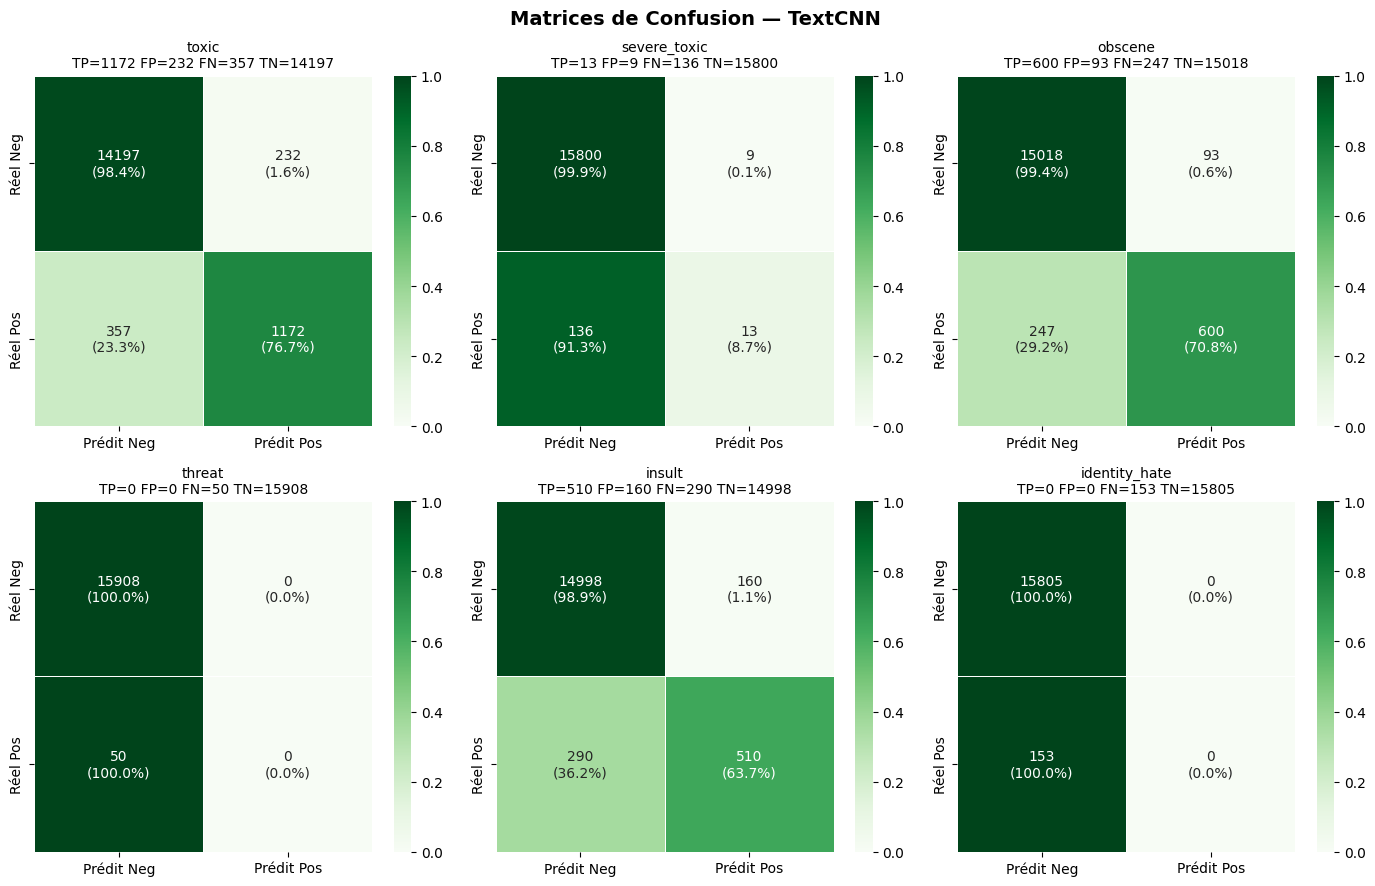

In [ ]:
# Matrices de confusion
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, label in enumerate(LABELS):
    cm = confusion_matrix(y_val[:, idx], results_cnn['y_pred'][:, idx])
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    annot = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)'
                       for j in range(2)] for i in range(2)])
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Greens',
                ax=axes[idx], vmin=0, vmax=1, linewidths=0.5,
                xticklabels=['Prédit Neg', 'Prédit Pos'],
                yticklabels=['Réel Neg', 'Réel Pos'])
    tn, fp, fn, tp = cm.ravel()
    axes[idx].set_title(f'{label}\nTP={tp} FP={fp} FN={fn} TN={tn}', fontsize=10)

plt.suptitle('Matrices de Confusion — TextCNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cnn_confusion.png'), dpi=150)
plt.show()

## 8. 💾 Sauvegarde

In [ ]:
test_preds = model_cnn.predict(X_test_pad, batch_size=512, verbose=1)
sub_df = pd.DataFrame(test_preds, columns=LABELS)
sub_df.insert(0, 'id', test_df['id'])
sub_df.to_csv(os.path.join(RESULTS_DIR, 'submission_cnn.csv'), index=False)

pd.DataFrame([{
    'model': 'CNN',
    'roc_auc_macro': results_cnn['roc_auc_macro'],
    'f1_macro':      results_cnn['f1_macro'],
    'f1_micro':      results_cnn['f1_micro'],
    'f1_weighted':   results_cnn['f1_weighted'],
    'train_time_min': round(train_time_cnn / 60, 2),
    'n_params':       model_cnn.count_params()
}]).to_csv(os.path.join(RESULTS_DIR, 'metrics_cnn.csv'), index=False)
print('✅ Fichiers sauvegardés :')
print('   best_cnn.keras | cnn_history.png | cnn_confusion.png')
print('   submission_cnn.csv | metrics_cnn.csv')
print(f'\n📊 ROC-AUC final : {results_cnn["roc_auc_macro"]:.4f}')

300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step
✅ Fichiers sauvegardés :
   best_cnn.keras | cnn_history.png | cnn_confusion.png
   submission_cnn.csv | metrics_cnn.csv

📊 ROC-AUC final : 0.9741
